In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tsm_toolkit import TraceReader, TsmAnalysis, TsmPlotter
import os

# Display directory containing the data

path = '/home/maxi/Documents/psi_hipa_tsm/code/data/time_structure_measurement/20260702'
measurements = next(os.walk(path))[1]
measurements

['20260702_MXZ1_mxz2@home_trglvl_-3.0V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@home_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V',
 '20260702_MXZ1_mxz2@0mm_trglvl_-.17V_Ibeam_1.4mA_Voff_3.8V_Vbias_700V']

In [3]:
# Select sample to process from list

sample = '20260702_MXZ1_mxz2@0mm_trglvl_-3.0V_Ibeam_2.2mA_Voff_3.8V_Vbias_700V'


# Load scope-data to pandas DataFrame using the TraceReader class

chn_pmt = 3
chn_rf = 1

Trace = TraceReader(os.path.join(path, sample), chn=chn_pmt)
pmt = Trace.load_traces()

Trace = TraceReader(os.path.join(path, sample), chn=chn_rf)
rf = Trace.load_traces()

# Initialize TsmAnalysis, combining both dataframes into a single one without redundant information.
# Compute basic information of pmt waveforms, e.g. pulse amplitude, baseline, etc. and save them in a dedicated column

Tsm = TsmAnalysis(pmt, rf)
df = Tsm.df


100%|██████████| 10148/10148 [00:00<00:00, 30642.51it/s]


Estimating pulse arival times


100%|██████████| 10148/10148 [00:08<00:00, 1216.41it/s]


No corresction applied in 0 cases
Calculating pulse timing w.r.t. RF


100%|██████████| 10148/10148 [00:18<00:00, 542.39it/s]


No estimate preduced in 0 instances


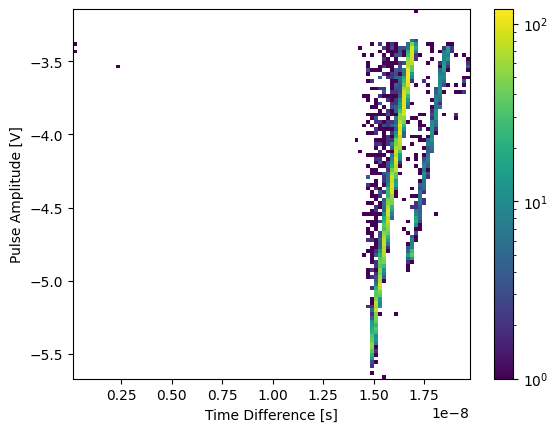

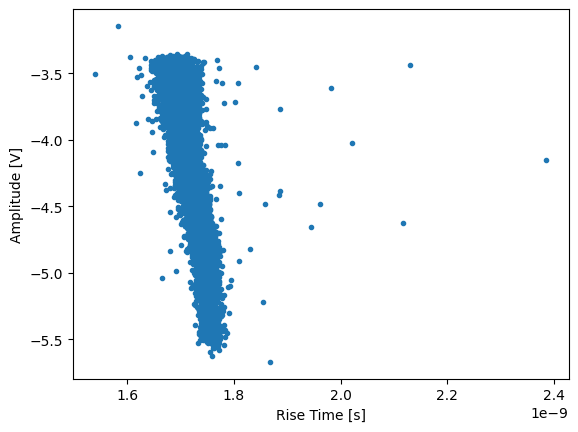

In [4]:
# Compute time difference between 0-phase of reference signal and the pulse arrival time of the PMT.
# To correct for discriminator walk, select option timing="corrected". For scope-inherent LED trigger choose "original"
# edit cfd_bounds (default (0.1, 0.9), corresponding to the definition of pulse rise time in Hamamatsu's PMT Handbook 4.E)

Tsm.get_rf_timing(timing='corrected', cfd_bounds=(0.2, 0.8))

df.columns

mask = df.fit_misalignment > -5e-11

plotter = TsmPlotter(df[mask])

plotter.tsm_hist2d()

plt.scatter(df.rise_time[mask], df.amp[mask], marker='.')
plt.xlabel('Rise Time [s]')
plt.ylabel('Amplitude [V]')
# plt.xlim(1e-9,4e-9)
plt.show()
